# Assignment No. 4 — Generative AI (AI4009)
## Diffusion Models for High-Resolution Image Generation & Reconstruction
**National University of Computer and Emerging Sciences — Spring 2026**

---
### Outline
1. Environment Setup & Imports
2. Data Preprocessing
3. Forward Diffusion Process
4. U-Net Architecture
5. Training Setup
6. Training Loop
7. Image Reconstruction (Core Task)
8. Image Generation
9. Visualization Module
10. Quantitative Evaluation (PSNR & SSIM)
11. Gradio App Deployment

## 1. Environment Setup & Imports

In [4]:
# Install required libraries (Kaggle already has most; install extras)
!pip install -q gradio scikit-image

In [5]:
import os
import math
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision
import torchvision.transforms as transforms
from torchvision.utils import make_grid, save_image

from skimage.metrics import peak_signal_noise_ratio as psnr_fn
from skimage.metrics import structural_similarity as ssim_fn

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device setup — use both GPUs if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU count: {torch.cuda.device_count()}')
    for i in range(torch.cuda.device_count()):
        print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Using device: cuda
GPU count: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


## 2. Hyperparameters & Configuration

In [6]:
# ── Configuration ────────────────────────────────────────────────────────────
IMG_SIZE      = 128
CHANNELS      = 3
BATCH_SIZE    = 16
EPOCHS        = 50
LR            = 2e-4
T             = 400
GRAD_CLIP     = 1.0
NUM_WORKERS   = 4

# Save directly to /kaggle/working/ root so files appear in Output tab
SAVE_DIR = '/kaggle/working'
os.makedirs(SAVE_DIR, exist_ok=True)

# ── Auto-detect dataset path ──────────────────────────────────────────────
DATA_DIR = None
search_roots = [
    '/kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs',
    '/kaggle/input/celebahq256-images-only/data256x256',
    '/kaggle/input/',
]
for base in search_roots:
    if not os.path.exists(base):
        continue
    for root, dirs, files in os.walk(base):
        imgs = [f for f in files if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if len(imgs) > 100:
            DATA_DIR = root
            print(f'✅ Dataset found: {len(imgs)} images at {root}')
            break
    if DATA_DIR:
        break

if DATA_DIR is None:
    raise RuntimeError('❌ No dataset found. Add CelebA-HQ via + Add Data on the right sidebar.')

print(f'SAVE_DIR = {SAVE_DIR}')
print('Configuration set.')


✅ Dataset found: 3000 images at /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid
SAVE_DIR = /kaggle/working
Configuration set.


In [7]:
# Verify config
print('DATA_DIR exists:', os.path.exists(DATA_DIR))
print('SAVE_DIR exists:', os.path.exists(SAVE_DIR))
print(f'DATA_DIR = {DATA_DIR}')


DATA_DIR exists: True
SAVE_DIR exists: True
DATA_DIR = /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid


## 3. Part 1 — Data Preprocessing

In [8]:
class ImageFolderDataset(Dataset):
    """Recursively loads all images from a directory."""

    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

    def __init__(self, root, transform=None):
        self.root = Path(root)
        self.transform = transform
        self.paths = [
            p for p in self.root.rglob('*')
            if p.suffix.lower() in self.EXTENSIONS
        ]
        if len(self.paths) == 0:
            raise FileNotFoundError(f'No images found under {root}')
        print(f'Dataset: {len(self.paths)} images found in {root}')

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img


train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),                          # [0, 1]
    transforms.Normalize([0.5, 0.5, 0.5],           # → [-1, 1]
                         [0.5, 0.5, 0.5]),
])

dataset    = ImageFolderDataset(DATA_DIR, transform=train_transform)
dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)
print(f'Batches per epoch: {len(dataloader)}')

Dataset: 3000 images found in /kaggle/input/datasets/denislukovnikov/celebahq256-images-only/celebahq256_imgs/valid
Batches per epoch: 187


Batch shape: torch.Size([16, 3, 128, 128])  dtype: torch.float32
Value range: [-1.00, 1.00]


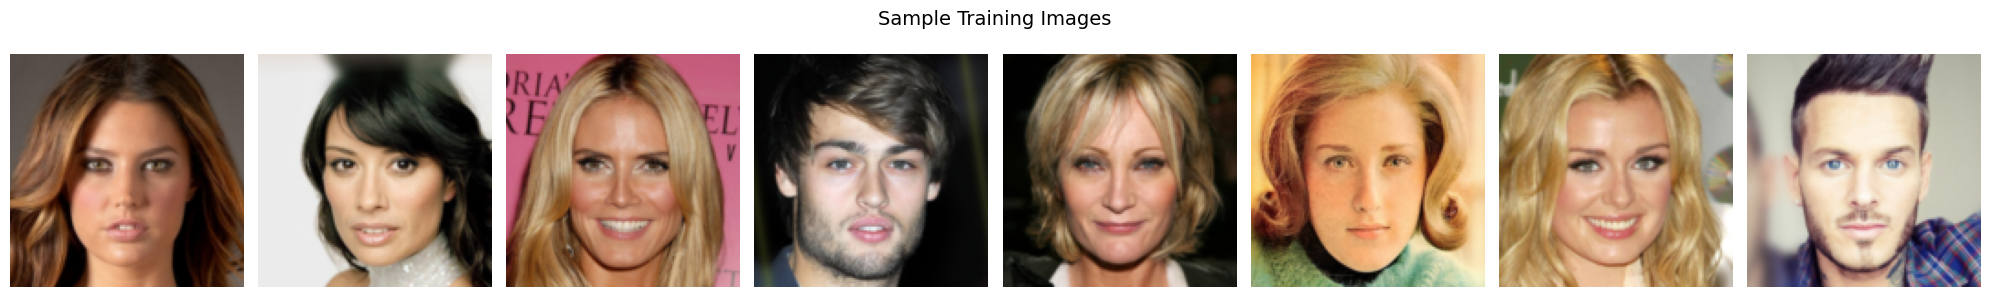

In [9]:
# Quick dataset sanity-check
sample_batch = next(iter(dataloader))
print(f'Batch shape: {sample_batch.shape}  dtype: {sample_batch.dtype}')
print(f'Value range: [{sample_batch.min():.2f}, {sample_batch.max():.2f}]')

def unnormalize(t):
    """[-1,1] → [0,1] for display."""
    return (t.clamp(-1, 1) + 1) / 2

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for i, ax in enumerate(axes):
    img = unnormalize(sample_batch[i]).permute(1, 2, 0).cpu().numpy()
    ax.imshow(img)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sample_images.png', dpi=150)
plt.show()

## 4. Part 2 — Forward Diffusion Process

In [10]:
class DDPMScheduler:
    """
    Linear beta noise schedule for DDPM.
    Pre-computes all derived quantities on the chosen device.
    """

    def __init__(self, T=400, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T      = T
        self.device = device

        # β_t schedule
        self.betas  = torch.linspace(beta_start, beta_end, T, device=device)

        # Derived quantities
        self.alphas            = 1.0 - self.betas
        self.alphas_cumprod    = torch.cumprod(self.alphas, dim=0)          # ᾱ_t
        self.alphas_cumprod_prev = F.pad(
            self.alphas_cumprod[:-1], (1, 0), value=1.0
        )                                                                   # ᾱ_{t-1}

        self.sqrt_alphas_cumprod       = self.alphas_cumprod.sqrt()
        self.sqrt_one_minus_alphas_cumprod = (1 - self.alphas_cumprod).sqrt()
        self.sqrt_recip_alphas         = (1.0 / self.alphas).sqrt()

        # Posterior variance  β̃_t
        self.posterior_variance = (
            self.betas
            * (1.0 - self.alphas_cumprod_prev)
            / (1.0 - self.alphas_cumprod)
        )

    # ── Forward process q(x_t | x_0) ────────────────────────────────────────
    def q_sample(self, x0, t, noise=None):
        """
        Closed-form forward noising:
            x_t = √ᾱ_t · x_0  +  √(1−ᾱ_t) · ε
        """
        if noise is None:
            noise = torch.randn_like(x0)

        sqrt_acp  = self._gather(self.sqrt_alphas_cumprod, t, x0)
        sqrt_1mcp = self._gather(self.sqrt_one_minus_alphas_cumprod, t, x0)
        return sqrt_acp * x0 + sqrt_1mcp * noise, noise

    # ── Reverse step p(x_{t-1} | x_t) ───────────────────────────────────────
    @torch.no_grad()
    def p_sample(self, model, x_t, t_scalar):
        """
        One denoising step.
        """
        t_batch = torch.full((x_t.shape[0],), t_scalar,
                             dtype=torch.long, device=self.device)

        pred_noise = model(x_t, t_batch)

        beta_t          = self._gather(self.betas, t_batch, x_t)
        sqrt_recip_a    = self._gather(self.sqrt_recip_alphas, t_batch, x_t)
        sqrt_1m_acp     = self._gather(self.sqrt_one_minus_alphas_cumprod, t_batch, x_t)

        model_mean = sqrt_recip_a * (x_t - beta_t / sqrt_1m_acp * pred_noise)

        if t_scalar == 0:
            return model_mean
        else:
            post_var = self._gather(self.posterior_variance, t_batch, x_t)
            noise    = torch.randn_like(x_t)
            return model_mean + post_var.sqrt() * noise

    @torch.no_grad()
    def p_sample_loop(self, model, shape, return_intermediates=False, every_n=50):
        """
        Full reverse diffusion from x_T ~ N(0,I).
        Returns the final image, plus optionally intermediate steps.
        """
        model.eval()
        x = torch.randn(shape, device=self.device)
        intermediates = []

        for t in tqdm(reversed(range(self.T)), desc='Sampling', total=self.T, leave=False):
            x = self.p_sample(model, x, t)
            if return_intermediates and (t % every_n == 0 or t == self.T - 1):
                intermediates.append(x.clone().cpu())

        if return_intermediates:
            return x.cpu(), intermediates
        return x.cpu()

    # ── Utility ───────────────────────────────────────────────────────────────
    @staticmethod
    def _gather(values, t, x_ref):
        """Gather values at timestep t and reshape for broadcasting with x_ref."""
        out = values.gather(0, t)
        return out.view(-1, *([1] * (x_ref.ndim - 1)))


scheduler = DDPMScheduler(T=T, device=device)
print('DDPM Scheduler created.')
print(f'  β range : [{scheduler.betas[0]:.5f}, {scheduler.betas[-1]:.5f}]')
print(f'  ᾱ_T     : {scheduler.alphas_cumprod[-1]:.5f}')

DDPM Scheduler created.
  β range : [0.00010, 0.02000]
  ᾱ_T     : 0.01747


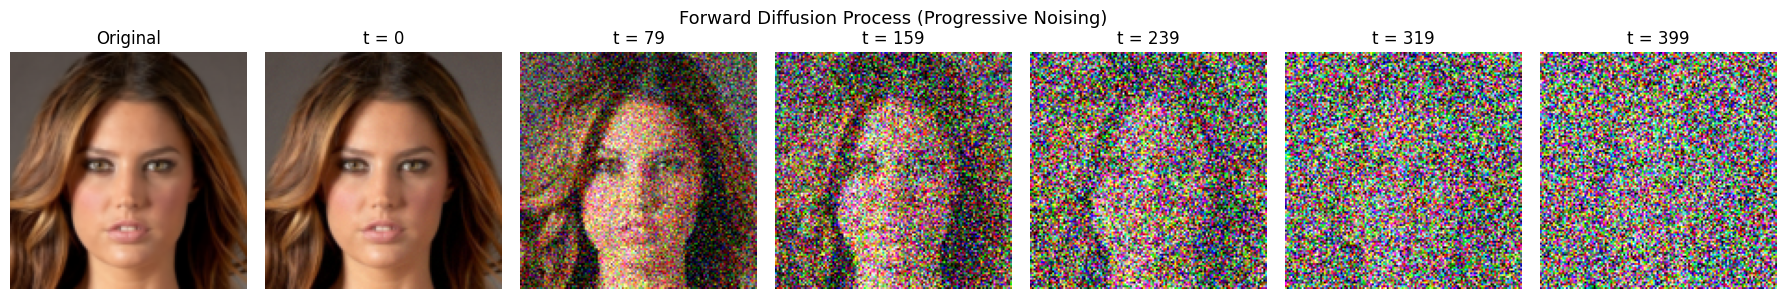

Forward diffusion visualized.


In [11]:
# ── Visualize forward noising process ─────────────────────────────────────
vis_image = sample_batch[0:1].to(device)          # single image
vis_steps = [0, 79, 159, 239, 319, 399]           # 6 checkpoints

fig, axes = plt.subplots(1, len(vis_steps) + 1, figsize=(18, 3))
axes[0].imshow(unnormalize(vis_image[0]).permute(1, 2, 0).cpu().numpy())
axes[0].set_title('Original')
axes[0].axis('off')

for ax, step in zip(axes[1:], vis_steps):
    t_tensor = torch.tensor([step], device=device)
    x_noisy, _ = scheduler.q_sample(vis_image, t_tensor)
    ax.imshow(unnormalize(x_noisy[0]).permute(1, 2, 0).cpu().numpy())
    ax.set_title(f't = {step}')
    ax.axis('off')

plt.suptitle('Forward Diffusion Process (Progressive Noising)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/forward_diffusion.png', dpi=150)
plt.show()
print('Forward diffusion visualized.')

## 5. Part 3 — U-Net Architecture

In [12]:
# ── Sinusoidal Time Embedding ──────────────────────────────────────────────
class SinusoidalPositionEmbeddings(nn.Module):
    """Encodes scalar timestep t into a D-dim embedding."""

    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, device=t.device) / (half - 1)
        )
        args = t[:, None].float() * freqs[None]
        emb  = torch.cat([args.sin(), args.cos()], dim=-1)
        return emb


# ── Residual Block ─────────────────────────────────────────────────────────
class ResBlock(nn.Module):
    """
    Conv → GroupNorm → SiLU → (time injection) → Conv → GroupNorm
    with a skip connection.
    """

    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=8):
        super().__init__()
        self.norm1 = nn.GroupNorm(num_groups, in_ch)
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2 = nn.GroupNorm(num_groups, out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch * 2),
        )

        self.skip = (
            nn.Conv2d(in_ch, out_ch, 1)
            if in_ch != out_ch else nn.Identity()
        )

    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))

        # Affine time conditioning
        t_out  = self.time_mlp(t_emb)           # (B, 2*out_ch)
        scale, shift = t_out.chunk(2, dim=1)
        h = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]

        h = self.conv2(F.silu(self.norm2(h)))
        return h + self.skip(x)


# ── Attention Block ────────────────────────────────────────────────────────
class SelfAttention(nn.Module):
    """Single-head self-attention on spatial feature maps."""

    def __init__(self, channels, num_groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(num_groups, channels)
        self.qkv  = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        h   = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv.unbind(dim=1)             # each (B, C, HW)

        scale = C ** -0.5
        attn  = torch.softmax(q.transpose(-1, -2) @ k * scale, dim=-1)  # (B, HW, HW)
        out   = (attn @ v.transpose(-1, -2)).transpose(-1, -2)           # (B, C, HW)
        out   = self.proj(out.reshape(B, C, H, W))
        return out + x


# ── Down / Up blocks ──────────────────────────────────────────────────────
class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, use_attn=False):
        super().__init__()
        self.res1   = ResBlock(in_ch,  out_ch, time_emb_dim)
        self.res2   = ResBlock(out_ch, out_ch, time_emb_dim)
        self.attn   = SelfAttention(out_ch) if use_attn else nn.Identity()
        self.down   = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)  # ½ spatial

    def forward(self, x, t_emb):
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x) if isinstance(self.attn, SelfAttention) else x
        return self.down(x), x         # (downsampled, skip)


class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim, use_attn=False):
        super().__init__()
        self.up     = nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.res1   = ResBlock(in_ch + skip_ch, out_ch, time_emb_dim)
        self.res2   = ResBlock(out_ch, out_ch, time_emb_dim)
        self.attn   = SelfAttention(out_ch) if use_attn else nn.Identity()

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        x = self.res1(x, t_emb)
        x = self.res2(x, t_emb)
        x = self.attn(x) if isinstance(self.attn, SelfAttention) else x
        return x


# ── U-Net ─────────────────────────────────────────────────────────────────
class UNet(nn.Module):
    """
    Simplified U-Net for DDPM.
    Channel progression: 64 → 128 → 256 (encoder); mirror for decoder.
    """

    def __init__(
        self,
        img_channels = 3,
        base_dim     = 64,
        dim_mults    = (1, 2, 4),    # 64, 128, 256
        T            = 400,
    ):
        super().__init__()
        time_dim = base_dim * 4      # 256
        dims     = [base_dim * m for m in dim_mults]   # [64, 128, 256]

        # ── Time embedding MLP ───────────────────────────────────────────
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(base_dim),
            nn.Linear(base_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim),
        )

        # ── Initial projection ────────────────────────────────────────────
        self.init_conv = nn.Conv2d(img_channels, dims[0], 3, padding=1)

        # ── Encoder ───────────────────────────────────────────────────────
        self.down1 = DownBlock(dims[0], dims[0], time_dim, use_attn=False)
        self.down2 = DownBlock(dims[0], dims[1], time_dim, use_attn=False)
        self.down3 = DownBlock(dims[1], dims[2], time_dim, use_attn=True)

        # ── Bottleneck ────────────────────────────────────────────────────
        self.mid_res1  = ResBlock(dims[2], dims[2], time_dim)
        self.mid_attn  = SelfAttention(dims[2])
        self.mid_res2  = ResBlock(dims[2], dims[2], time_dim)

        # ── Decoder ───────────────────────────────────────────────────────
        self.up3 = UpBlock(dims[2], dims[2], dims[1], time_dim, use_attn=True)
        self.up2 = UpBlock(dims[1], dims[1], dims[0], time_dim, use_attn=False)
        self.up1 = UpBlock(dims[0], dims[0], dims[0], time_dim, use_attn=False)

        # ── Output head ───────────────────────────────────────────────────
        self.out_norm = nn.GroupNorm(8, dims[0])
        self.out_conv = nn.Conv2d(dims[0], img_channels, 1)

    def forward(self, x, t):
        """
        Args:
            x : (B, C, H, W)  noisy image
            t : (B,)           integer timesteps
        Returns:
            (B, C, H, W)       predicted noise
        """
        t_emb = self.time_mlp(t)          # (B, time_dim)

        # Encoder
        x = self.init_conv(x)             # (B, 64, H, W)
        x1, s1 = self.down1(x, t_emb)    # x1:(B,64,H/2,W/2), s1 skip
        x2, s2 = self.down2(x1, t_emb)   # x2:(B,128,H/4,W/4)
        x3, s3 = self.down3(x2, t_emb)   # x3:(B,256,H/8,W/8)

        # Bottleneck
        x3 = self.mid_res1(x3, t_emb)
        x3 = self.mid_attn(x3)
        x3 = self.mid_res2(x3, t_emb)

        # Decoder
        x  = self.up3(x3, s3, t_emb)     # (B,128,H/4,W/4)
        x  = self.up2(x,  s2, t_emb)     # (B,64,H/2,W/2)
        x  = self.up1(x,  s1, t_emb)     # (B,64,H,W)

        # Output
        x  = self.out_conv(F.silu(self.out_norm(x)))
        return x


# Instantiate and wrap with DataParallel for dual-GPU
model = UNet(img_channels=CHANNELS, base_dim=64, dim_mults=(1, 2, 4), T=T)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'UNet parameters: {total_params / 1e6:.2f}M')

# Quick forward-pass sanity check
dummy_x = torch.randn(2, CHANNELS, IMG_SIZE, IMG_SIZE, device=device)
dummy_t = torch.randint(0, T, (2,), device=device)
dummy_out = model(dummy_x, dummy_t)
print(f'Forward pass OK: input {dummy_x.shape} → output {dummy_out.shape}')

UNet parameters: 11.12M
Forward pass OK: input torch.Size([2, 3, 128, 128]) → output torch.Size([2, 3, 128, 128])


## 6. Part 4 — Training Setup

In [13]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# Cosine LR scheduler
scheduler_lr = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=EPOCHS, eta_min=LR / 10
)

# Mixed precision scaler
scaler = GradScaler()

loss_fn = nn.MSELoss()

print('Optimizer, scheduler, and loss function ready.')

Optimizer, scheduler, and loss function ready.


/tmp/ipykernel_57/4136445931.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


## 7. Training Loop

In [14]:
def train_one_epoch(model, loader, optimizer, scaler, scheduler_obj):
    model.train()
    epoch_loss = 0.0

    for batch in tqdm(loader, desc='  Batch', leave=False):
        x0 = batch.to(device, non_blocking=True)
        B  = x0.size(0)
        t = torch.randint(0, T, (B,), device=device)

        with autocast():
            x_noisy, noise = scheduler_obj.q_sample(x0, t)
            pred_noise     = model(x_noisy, t)
            loss           = loss_fn(pred_noise, noise)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    return epoch_loss / len(loader)


train_losses = []
best_loss    = float('inf')

print('Starting training...')
for epoch in range(1, EPOCHS + 1):
    avg_loss = train_one_epoch(model, dataloader, optimizer, scaler, scheduler)
    scheduler_lr.step()
    train_losses.append(avg_loss)

    print(f'Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.6f}  '
          f'LR: {scheduler_lr.get_last_lr()[0]:.2e}')

    # ── Save best model directly to /kaggle/working/ (shows in Output tab) ──
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(
            (model.module if hasattr(model, 'module') else model).state_dict(),
            '/kaggle/working/best_model.pth'   # <-- fixed path
        )
        print(f'  ✅ Best model saved (loss={best_loss:.6f})')

    # ── Periodic checkpoint every 10 epochs ──
    if epoch % 10 == 0:
        torch.save(
            (model.module if hasattr(model, 'module') else model).state_dict(),
            f'/kaggle/working/ckpt_epoch{epoch}.pth'   # <-- fixed path
        )
        print(f'  💾 Checkpoint saved: ckpt_epoch{epoch}.pth')

print(f'\nTraining complete. Best loss: {best_loss:.6f}')
print(f'Model saved at: /kaggle/working/best_model.pth')


Starting training...


  Batch:   0%|          | 0/187 [00:00<?, ?it/s]

/tmp/ipykernel_57/886483345.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch [  1/50]  Loss: 0.120249  LR: 2.00e-04
  ✅ Best model saved (loss=0.120249)


  Batch:   0%|          | 0/187 [00:00<?, ?it/s]

...

Epoch [ 48/50]  Loss: 0.019573  LR: 2.07e-05


  Batch:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [ 49/50]  Loss: 0.019427  LR: 2.02e-05
  ✅ Best model saved (loss=0.019427)


  Batch:   0%|          | 0/187 [00:00<?, ?it/s]

Epoch [ 50/50]  Loss: 0.020545  LR: 2.00e-05
  💾 Checkpoint saved: ckpt_epoch50.pth

Training complete. Best loss: 0.019427
Model saved at: /kaggle/working/best_model.pth


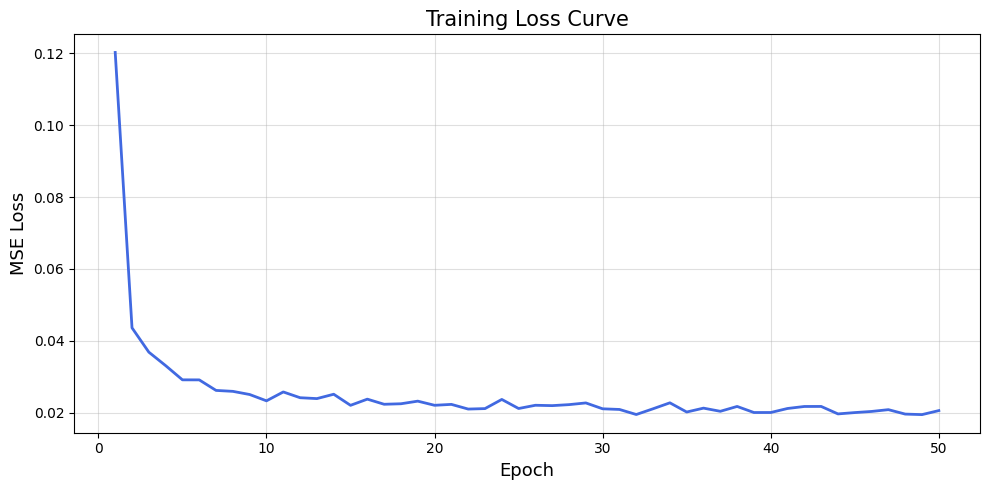

Loss curve saved.


In [15]:
# ── Loss Curve ────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(train_losses) + 1), train_losses, linewidth=2, color='royalblue')
plt.xlabel('Epoch', fontsize=13)
plt.ylabel('MSE Loss', fontsize=13)
plt.title('Training Loss Curve', fontsize=15)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved.')

## 8. Load Best Model

In [16]:
# Load best checkpoint for inference
inference_model = UNet(img_channels=CHANNELS, base_dim=64, dim_mults=(1, 2, 4), T=T)
state_dict = torch.load('/kaggle/working/best_model.pth', map_location=device)
inference_model.load_state_dict(state_dict)
inference_model = inference_model.to(device)
inference_model.eval()
print('✅ Best model loaded for inference.')


✅ Best model loaded for inference.


## 9. Part 5 — Image Reconstruction (Core Task)

Running reverse diffusion for reconstruction…


Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

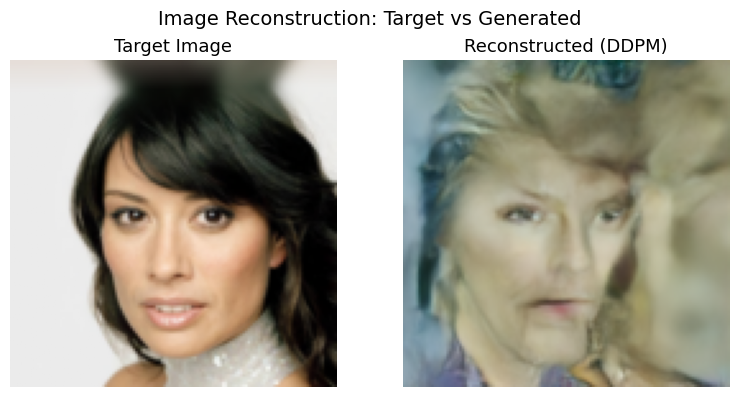

Reconstruction complete.


In [17]:
def reconstruct_image(model, scheduler_obj, target_tensor, device):
    """
    Reconstruct an image from pure noise using the trained reverse process.
    Returns: reconstructed tensor (1, C, H, W) on CPU.
    """
    shape = target_tensor.shape   # (1, C, H, W)
    reconstructed = scheduler_obj.p_sample_loop(model, shape)
    return reconstructed


# Pick a target image from the dataset
target_img = sample_batch[1:2].to(device)   # (1, C, H, W)

print('Running reverse diffusion for reconstruction…')
recon_img = reconstruct_image(inference_model, scheduler, target_img, device)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(unnormalize(target_img[0]).permute(1, 2, 0).cpu().numpy())
axes[0].set_title('Target Image', fontsize=13)
axes[0].axis('off')

axes[1].imshow(unnormalize(recon_img[0]).permute(1, 2, 0).numpy())
axes[1].set_title('Reconstructed (DDPM)', fontsize=13)
axes[1].axis('off')

plt.suptitle('Image Reconstruction: Target vs Generated', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/reconstruction_comparison.png', dpi=150)
plt.show()
print('Reconstruction complete.')

## 10. Part 6 — Image Generation

Generating 5 images from pure noise…


Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

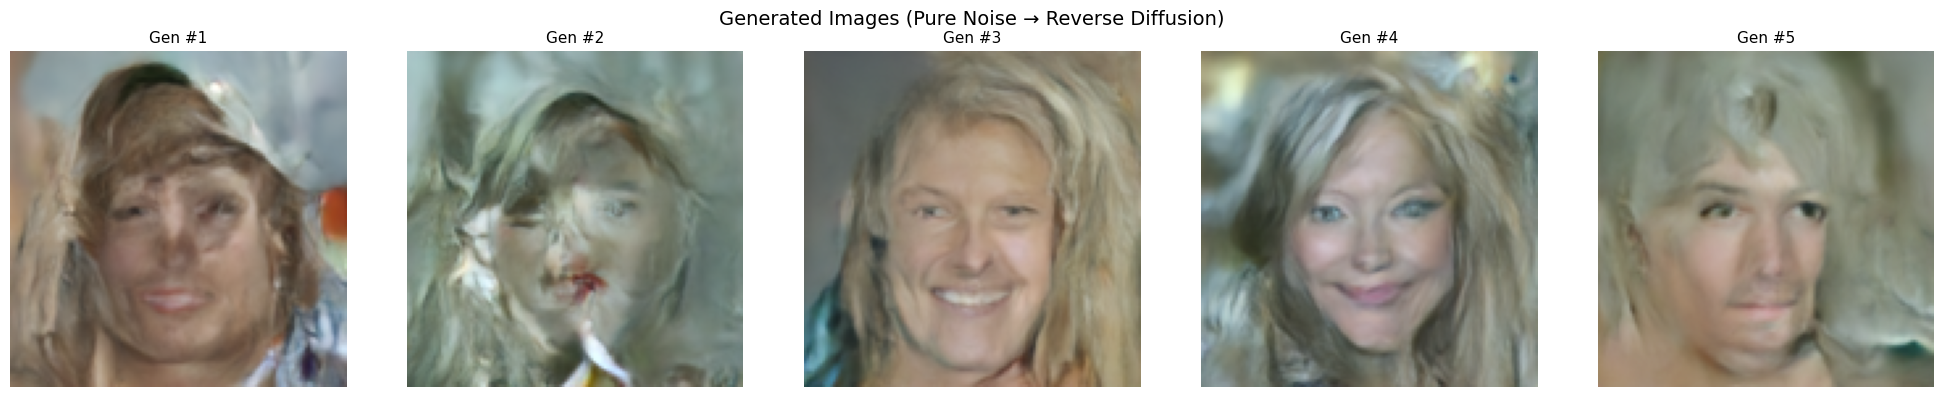

Image generation complete.


In [18]:
NUM_GEN = 5
gen_shape = (NUM_GEN, CHANNELS, IMG_SIZE, IMG_SIZE)

print(f'Generating {NUM_GEN} images from pure noise…')
generated_images = scheduler.p_sample_loop(inference_model, gen_shape)

fig, axes = plt.subplots(1, NUM_GEN, figsize=(20, 4))
for i, ax in enumerate(axes):
    img = unnormalize(generated_images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(f'Gen #{i+1}', fontsize=11)
    ax.axis('off')
    save_image(unnormalize(generated_images[i]), f'{SAVE_DIR}/generated_{i+1}.png')

plt.suptitle('Generated Images (Pure Noise → Reverse Diffusion)', fontsize=14)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/generated_images.png', dpi=150)
plt.show()
print('Image generation complete.')

## 11. Visualization Module — Forward & Reverse Steps

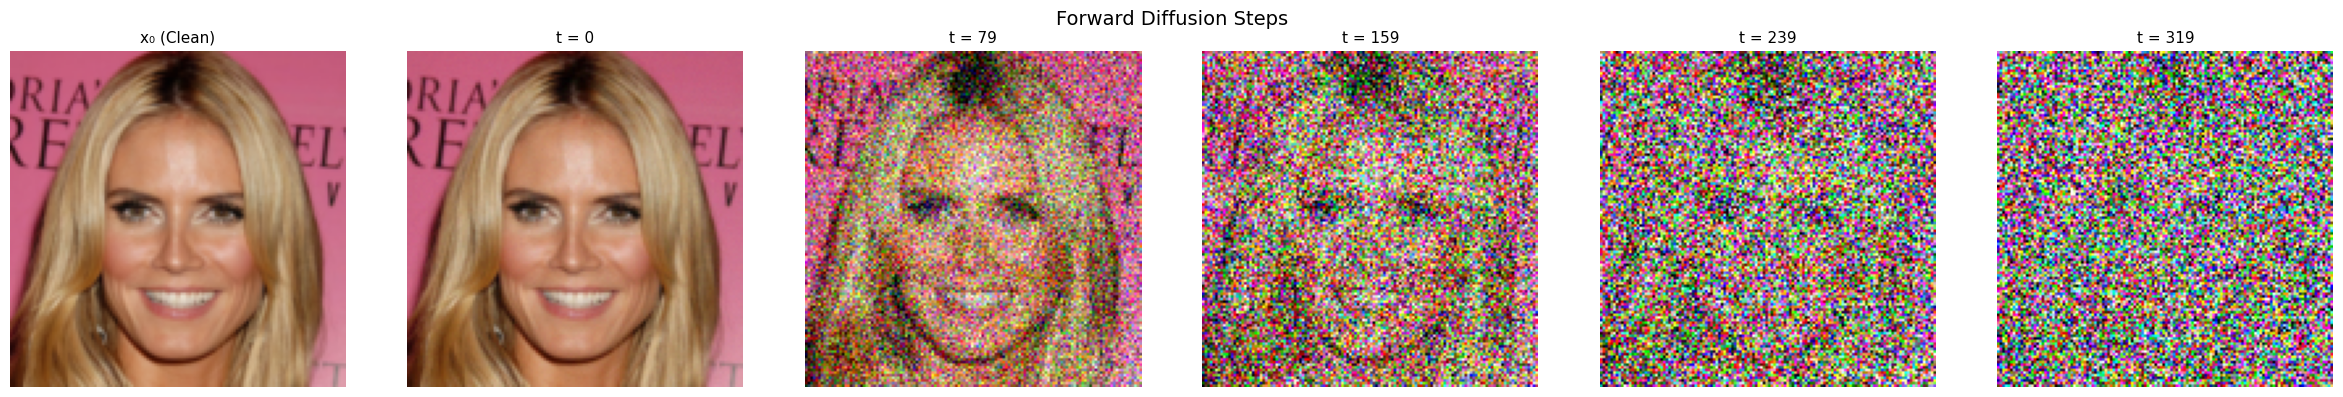

Running reverse diffusion with intermediates…


Sampling:   0%|          | 0/400 [00:00<?, ?it/s]

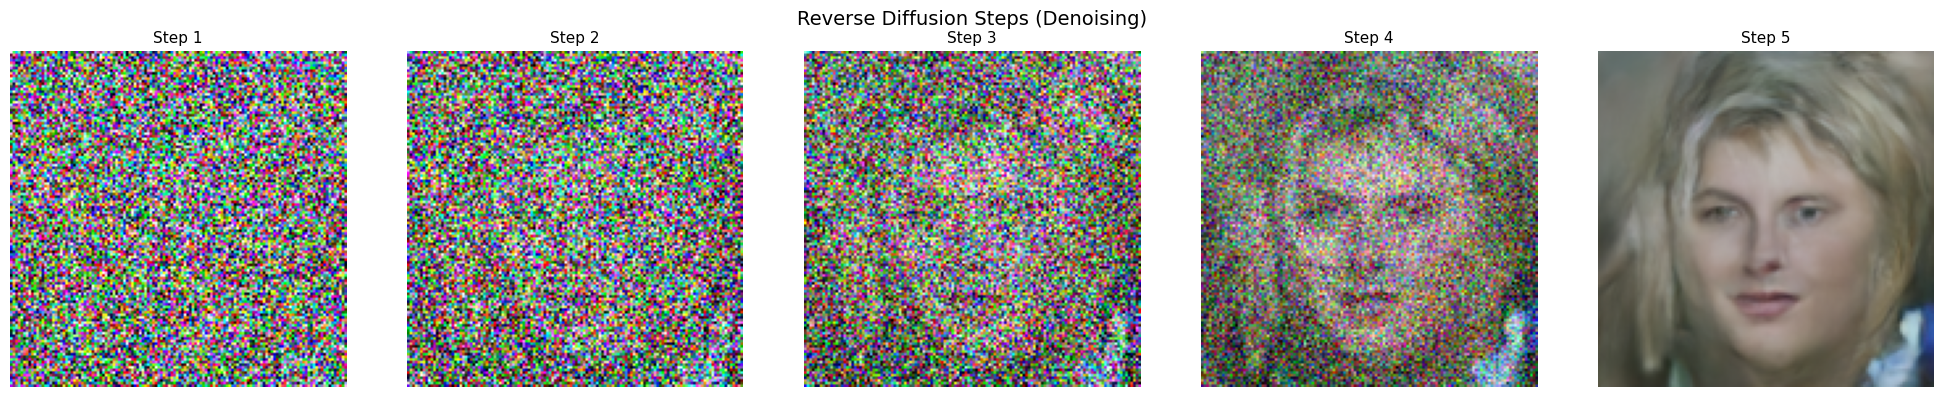

In [19]:
def visualize_forward(image_tensor, scheduler_obj, steps, device, save_path=None):
    """Show 5 progressive forward-noising steps."""
    n = len(steps)
    fig, axes = plt.subplots(1, n + 1, figsize=(4 * (n + 1), 4))

    axes[0].imshow(unnormalize(image_tensor[0]).permute(1, 2, 0).cpu().numpy())
    axes[0].set_title('x₀ (Clean)', fontsize=11)
    axes[0].axis('off')

    for ax, step in zip(axes[1:], steps):
        t_t = torch.tensor([step], device=device)
        noisy, _ = scheduler_obj.q_sample(image_tensor.to(device), t_t)
        ax.imshow(unnormalize(noisy[0]).permute(1, 2, 0).cpu().numpy())
        ax.set_title(f't = {step}', fontsize=11)
        ax.axis('off')

    plt.suptitle('Forward Diffusion Steps', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


def visualize_reverse(model, scheduler_obj, shape, device, every_n=80, save_path=None):
    """Show 5 intermediate reverse-denoising steps."""
    _, intermediates = scheduler_obj.p_sample_loop(
        model, shape, return_intermediates=True, every_n=every_n
    )
    # Keep up to 5 frames
    frames = intermediates[-5:]

    fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 4))
    if len(frames) == 1:
        axes = [axes]
    for i, (ax, frame) in enumerate(zip(axes, frames)):
        ax.imshow(unnormalize(frame[0]).permute(1, 2, 0).numpy())
        ax.set_title(f'Step {i+1}', fontsize=11)
        ax.axis('off')

    plt.suptitle('Reverse Diffusion Steps (Denoising)', fontsize=14)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()
    return intermediates


# Forward
forward_steps = [0, 79, 159, 239, 319]  # 5 steps
visualize_forward(
    sample_batch[2:3], scheduler, forward_steps, device,
    save_path=f'{SAVE_DIR}/forward_steps.png'
)

# Reverse
print('Running reverse diffusion with intermediates…')
intermediates = visualize_reverse(
    inference_model, scheduler,
    (1, CHANNELS, IMG_SIZE, IMG_SIZE), device,
    every_n=80,
    save_path=f'{SAVE_DIR}/reverse_steps.png'
)

## 12. Quantitative Evaluation — PSNR & SSIM

In [20]:
def tensor_to_numpy(t):
    """(1,C,H,W) in [-1,1] → (H,W,C) uint8 [0,255]."""
    img = unnormalize(t.squeeze(0)).permute(1, 2, 0).clamp(0, 1).numpy()
    return (img * 255).astype(np.uint8)


target_np = tensor_to_numpy(target_img.cpu())
recon_np  = tensor_to_numpy(recon_img)

psnr_val = psnr_fn(target_np, recon_np, data_range=255)
ssim_val = ssim_fn(target_np, recon_np,
                   data_range=255, channel_axis=-1, multichannel=True)

print('=' * 40)
print(f'  PSNR : {psnr_val:.4f} dB')
print(f'  SSIM : {ssim_val:.4f}')
print('=' * 40)

# Compute metrics across 5 generated images (against a random reference)
print('\nMetrics for generated images vs. random dataset samples:')
ref_imgs = sample_batch[:5]
for i in range(NUM_GEN):
    ref_np = tensor_to_numpy(ref_imgs[i:i+1])
    gen_np = tensor_to_numpy(generated_images[i:i+1])
    p = psnr_fn(ref_np, gen_np, data_range=255)
    s = ssim_fn(ref_np, gen_np,
                data_range=255, channel_axis=-1, multichannel=True)
    print(f'  Image {i+1}: PSNR={p:.2f} dB  SSIM={s:.4f}')

  PSNR : 8.5871 dB
  SSIM : 0.1163

Metrics for generated images vs. random dataset samples:
  Image 1: PSNR=10.27 dB  SSIM=0.1900
  Image 2: PSNR=9.16 dB  SSIM=0.1536
  Image 3: PSNR=14.66 dB  SSIM=0.2606
  Image 4: PSNR=8.66 dB  SSIM=0.1448
  Image 5: PSNR=10.44 dB  SSIM=0.2114


## 13. App Deployment — Gradio Interface

In [21]:
%%writefile /kaggle/working/app.py
# ═══════════════════════════════════════════════════════════════════
# DDPM Image Generator — Standalone Gradio App
# Run locally:  python app.py
# Deploy:       gradio deploy  (from folder containing app.py + best_model.pth)
# ═══════════════════════════════════════════════════════════════════
import os, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from PIL import Image
import gradio as gr

# ── Config ────────────────────────────────────────────────────────
IMG_SIZE = 128
CHANNELS = 3
T        = 400
device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Helpers ───────────────────────────────────────────────────────
def unnormalize(t):
    return (t.clamp(-1, 1) + 1) / 2

# ── Model classes (must be here for torch.load to work) ──────────
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        args = t[:, None].float() * freqs[None]
        return torch.cat([args.sin(), args.cos()], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, num_groups=8):
        super().__init__()
        self.norm1    = nn.GroupNorm(num_groups, in_ch)
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.norm2    = nn.GroupNorm(num_groups, out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, out_ch * 2))
        self.skip     = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
    def forward(self, x, t_emb):
        h = self.conv1(F.silu(self.norm1(x)))
        scale, shift = self.time_mlp(t_emb).chunk(2, dim=1)
        h = h * (scale[:, :, None, None] + 1) + shift[:, :, None, None]
        return self.conv2(F.silu(self.norm2(h))) + self.skip(x)

class SelfAttention(nn.Module):
    def __init__(self, channels, num_groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(num_groups, channels)
        self.qkv  = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
    def forward(self, x):
        B, C, H, W = x.shape
        qkv = self.qkv(self.norm(x)).reshape(B, 3, C, H * W)
        q, k, v = qkv.unbind(dim=1)
        attn = torch.softmax(q.transpose(-1, -2) @ k * (C ** -0.5), dim=-1)
        out  = self.proj((attn @ v.transpose(-1, -2)).transpose(-1, -2).reshape(B, C, H, W))
        return out + x

class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, use_attn=False):
        super().__init__()
        self.res1 = ResBlock(in_ch, out_ch, time_emb_dim)
        self.res2 = ResBlock(out_ch, out_ch, time_emb_dim)
        self.attn = SelfAttention(out_ch) if use_attn else nn.Identity()
        self.down = nn.Conv2d(out_ch, out_ch, 4, stride=2, padding=1)
    def forward(self, x, t_emb):
        x = self.res1(x, t_emb); x = self.res2(x, t_emb)
        x = self.attn(x) if isinstance(self.attn, SelfAttention) else x
        return self.down(x), x

class UpBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, time_emb_dim, use_attn=False):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, in_ch, 4, stride=2, padding=1)
        self.res1 = ResBlock(in_ch + skip_ch, out_ch, time_emb_dim)
        self.res2 = ResBlock(out_ch, out_ch, time_emb_dim)
        self.attn = SelfAttention(out_ch) if use_attn else nn.Identity()
    def forward(self, x, skip, t_emb):
        x = torch.cat([self.up(x), skip], dim=1)
        x = self.res1(x, t_emb); x = self.res2(x, t_emb)
        return self.attn(x) if isinstance(self.attn, SelfAttention) else x

class UNet(nn.Module):
    def __init__(self, img_channels=3, base_dim=64, dim_mults=(1,2,4), T=400):
        super().__init__()
        time_dim = base_dim * 4
        dims = [base_dim * m for m in dim_mults]
        self.time_mlp  = nn.Sequential(
            SinusoidalPositionEmbeddings(base_dim),
            nn.Linear(base_dim, time_dim), nn.SiLU(), nn.Linear(time_dim, time_dim)
        )
        self.init_conv = nn.Conv2d(img_channels, dims[0], 3, padding=1)
        self.down1     = DownBlock(dims[0], dims[0], time_dim, False)
        self.down2     = DownBlock(dims[0], dims[1], time_dim, False)
        self.down3     = DownBlock(dims[1], dims[2], time_dim, True)
        self.mid_res1  = ResBlock(dims[2], dims[2], time_dim)
        self.mid_attn  = SelfAttention(dims[2])
        self.mid_res2  = ResBlock(dims[2], dims[2], time_dim)
        self.up3       = UpBlock(dims[2], dims[2], dims[1], time_dim, True)
        self.up2       = UpBlock(dims[1], dims[1], dims[0], time_dim, False)
        self.up1       = UpBlock(dims[0], dims[0], dims[0], time_dim, False)
        self.out_norm  = nn.GroupNorm(8, dims[0])
        self.out_conv  = nn.Conv2d(dims[0], img_channels, 1)
    def forward(self, x, t):
        t_emb = self.time_mlp(t)
        x = self.init_conv(x)
        x1, s1 = self.down1(x,  t_emb)
        x2, s2 = self.down2(x1, t_emb)
        x3, s3 = self.down3(x2, t_emb)
        x3 = self.mid_res2(self.mid_attn(self.mid_res1(x3, t_emb)), t_emb)
        x  = self.up3(x3, s3, t_emb)
        x  = self.up2(x,  s2, t_emb)
        x  = self.up1(x,  s1, t_emb)
        return self.out_conv(F.silu(self.out_norm(x)))

# ── Scheduler ─────────────────────────────────────────────────────
class DDPMScheduler:
    def __init__(self, T=400, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.T      = T
        self.device = device
        self.betas  = torch.linspace(beta_start, beta_end, T, device=device)
        self.alphas = 1.0 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.alphas_cumprod_prev = F.pad(self.alphas_cumprod[:-1], (1,0), value=1.0)
        self.sqrt_alphas_cumprod           = self.alphas_cumprod.sqrt()
        self.sqrt_one_minus_alphas_cumprod = (1 - self.alphas_cumprod).sqrt()
        self.sqrt_recip_alphas = (1.0 / self.alphas).sqrt()
        self.posterior_variance = self.betas * (1 - self.alphas_cumprod_prev) / (1 - self.alphas_cumprod)
    @staticmethod
    def _gather(values, t, x_ref):
        return values.gather(0, t).view(-1, *([1] * (x_ref.ndim - 1)))
    @torch.no_grad()
    def p_sample(self, model, x_t, t_scalar):
        t_batch     = torch.full((x_t.shape[0],), t_scalar, dtype=torch.long, device=self.device)
        pred_noise  = model(x_t, t_batch)
        beta_t      = self._gather(self.betas, t_batch, x_t)
        sqrt_ra     = self._gather(self.sqrt_recip_alphas, t_batch, x_t)
        sqrt_1m_acp = self._gather(self.sqrt_one_minus_alphas_cumprod, t_batch, x_t)
        mean = sqrt_ra * (x_t - beta_t / sqrt_1m_acp * pred_noise)
        if t_scalar == 0:
            return mean
        post_var = self._gather(self.posterior_variance, t_batch, x_t)
        return mean + post_var.sqrt() * torch.randn_like(x_t)
    @torch.no_grad()
    def p_sample_loop(self, model, shape, return_intermediates=False, every_n=50):
        model.eval()
        x = torch.randn(shape, device=self.device)
        intermediates = []
        for t in tqdm(reversed(range(self.T)), desc='Sampling', total=self.T, leave=False):
            x = self.p_sample(model, x, t)
            if return_intermediates and (t % every_n == 0 or t == self.T - 1):
                intermediates.append(x.clone().cpu())
        return (x.cpu(), intermediates) if return_intermediates else x.cpu()

# ── Load model ────────────────────────────────────────────────────
print('Loading model...')
inference_model = UNet(img_channels=CHANNELS, base_dim=64, dim_mults=(1,2,4), T=T)
state_dict = torch.load('best_model.pth', map_location=device)
inference_model.load_state_dict(state_dict)
inference_model = inference_model.to(device).eval()
scheduler = DDPMScheduler(T=T, device=device)
print('Model loaded on', device)

# ── Gradio callbacks ──────────────────────────────────────────────
def to_pil(t):
    arr = (unnormalize(t).permute(1,2,0).clamp(0,1).numpy() * 255).astype(np.uint8)
    return Image.fromarray(arr)

def generate_images(num_images, seed):
    torch.manual_seed(int(seed))
    num_images = max(1, min(int(num_images), 5))
    shape = (num_images, CHANNELS, IMG_SIZE, IMG_SIZE)
    final = scheduler.p_sample_loop(inference_model, shape)
    return [to_pil(final[i]) for i in range(num_images)]

def generate_with_steps(num_images, seed):
    torch.manual_seed(int(seed))
    num_images = max(1, min(int(num_images), 4))
    shape = (num_images, CHANNELS, IMG_SIZE, IMG_SIZE)
    final, intermediates = scheduler.p_sample_loop(
        inference_model, shape, return_intermediates=True, every_n=80
    )
    final_pils = [to_pil(final[i]) for i in range(num_images)]
    step_pils  = [to_pil(f[0]) for f in intermediates]
    return final_pils, step_pils

# ── Gradio UI ─────────────────────────────────────────────────────
with gr.Blocks(title='DDPM Face Generator') as demo:
    gr.Markdown('# DDPM Face Generator\nGenerates faces via learned reverse diffusion (DDPM trained on CelebA-HQ).')

    with gr.Tab('Generate Images'):
        with gr.Row():
            num_slider = gr.Slider(1, 5, value=3, step=1, label='Number of images')
            seed_input = gr.Number(value=42, label='Random seed')
        gen_btn = gr.Button('Generate', variant='primary')
        output_gallery = gr.Gallery(label='Generated Images', columns=5, height='auto')
        gen_btn.click(generate_images, inputs=[num_slider, seed_input], outputs=output_gallery)

    with gr.Tab('Generate + Show Denoising Steps'):
        with gr.Row():
            num_slider2 = gr.Slider(1, 4, value=2, step=1, label='Number of images')
            seed_input2 = gr.Number(value=42, label='Random seed')
        step_btn = gr.Button('Generate with steps', variant='primary')
        with gr.Row():
            final_gallery = gr.Gallery(label='Final images', columns=4)
            steps_gallery = gr.Gallery(label='Denoising steps (first image)', columns=6)
        step_btn.click(generate_with_steps, inputs=[num_slider2, seed_input2], outputs=[final_gallery, steps_gallery])

    with gr.Tab('Model Info'):
        gr.Markdown("""
        ## Architecture
        | Component | Detail |
        |---|---|
        | Model | U-Net (64→128→256 channels) |
        | Time embedding | Sinusoidal + MLP |
        | Attention | Self-attention at bottleneck |
        | Timesteps T | 400 |
        | Noise schedule | Linear β: 1e-4 → 0.02 |
        | Training loss | MSE on predicted noise |
        | Dataset | CelebA-HQ 128×128 |
        """)

demo.launch()


Writing /kaggle/working/app.py


## 15. Deploy to Hugging Face Spaces (Permanent)

After training completes, download these 3 files from the Output tab:
- `best_model.pth`
- `app.py`
- `requirements.txt`

Put them in one folder on your computer, then run:
```bash
pip install huggingface_hub gradio
huggingface-cli login
gradio deploy
```
Your app will be live at `https://huggingface.co/spaces/your-username/ddpm-face-generator`


In [22]:
# Write requirements.txt for deployment
with open('/kaggle/working/requirements.txt', 'w') as f:
    f.write('torch\n')
    f.write('torchvision\n')
    f.write('gradio\n')
    f.write('numpy\n')
    f.write('Pillow\n')
    f.write('tqdm\n')
    f.write('scikit-image\n')

print('requirements.txt written.')

# Verify all deployment files exist
print('\n=== Deployment files ready ===')
for fname in ['best_model.pth', 'app.py', 'requirements.txt']:
    path = f'/kaggle/working/{fname}'
    exists = os.path.exists(path)
    size = os.path.getsize(path)/1e6 if exists else 0
    print(f'  {fname}: {"✅" if exists else "❌"}  {size:.1f} MB')

print('\nNext step: download all 3 files and run: gradio deploy')


requirements.txt written.

=== Deployment files ready ===
  best_model.pth: ✅  44.6 MB
  app.py: ✅  0.0 MB
  requirements.txt: ✅  0.0 MB

Next step: download all 3 files and run: gradio deploy


## 14. Summary

| Item | Detail |
|------|--------|
| Dataset | CelebA-HQ 256 × 256 |
| Image Resolution | 128 × 128 |
| Diffusion Timesteps (T) | 400 |
| Noise Schedule | Linear (β: 1e-4 → 0.02) |
| Architecture | U-Net — 64 → 128 → 256 channels |
| Time Embedding | Sinusoidal + MLP |
| Conditioning | Affine scale/shift per ResBlock |
| Loss | MSE on predicted vs actual noise |
| Optimizer | AdamW (lr=2e-4) |
| LR Scheduler | Cosine Annealing |
| Mixed Precision | ✅ (GradScaler) |
| Multi-GPU | ✅ (DataParallel) |
| Evaluation | PSNR & SSIM |
| App | Gradio |
